In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

In [2]:
data_path = '../../data_one_channel'
train_data_path = '../../synt_one_channel_tiny_jet' #
val_data_path = '../../val_one_channel'

## Convolutional Neural Network

In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch
from torchvision import datasets, transforms
from torchvision.transforms import v2
import torch.optim as optim
from tqdm import tqdm

class CNN(nn.Module):
    def __init__(self) -> None:
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        
#         self.bn1 = nn.BatchNorm2d(16)
#         self.bn2 = nn.BatchNorm2d(32)
#         self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
#         self.conv6 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        
        self.fc1 = nn.Linear(128, 128)
        self.fc2 = nn.Linear(128, 4)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.2)
    
    def forward(self, image: torch.Tensor) -> torch.Tensor:
        image = self.conv1(image)
#         image = self.bn1(image)
        image = self.relu(image)
        image = self.pool(image)
        
        image = self.conv2(image)
#         image = self.bn2(image)
        image = self.relu(image)
        image = self.pool(image)
#         image = self.dropout(image)
        
        image = self.conv3(image)
#         image = self.bn3(image)
        image = self.relu(image)
        image = self.pool(image)
#         image = self.dropout(image)
        
        image = self.conv4(image)
        image = self.relu(image)
        image = self.pool(image)

        image = self.conv5(image)
        image = self.relu(image)
        image = self.pool(image)
        
#         image = self.conv6(image)
#         image = self.relu(image)
#         image = self.pool(image)
#         print(image.shape)

        image = image.view(-1, 128)
        image = self.fc1(image)
        image = self.relu(image)
        image = self.dropout(image)
        image = self.fc2(image)
        return F.log_softmax(image, dim=1)

In [4]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def draw_cm(y, preds, file_name='ConfMatrix') -> None:
    cm = confusion_matrix(y, preds)
    ConfusionMatrixDisplay(cm).plot()
    plt.savefig(f'{file_name}.png', dpi=500)

    precision = precision_score(y, preds, average='macro')
    recall = recall_score(y, preds, average='macro')

    f1 = 2 * precision * recall / (precision + recall)
    f1_macro = f1_score(y, preds, average='macro')
    f1_weighted = f1_score(y, preds, average='weighted')
    print(f'Precision: {100 * precision:.3f} %')
    print(f'Recall: {100 * recall:.3f} %')
    print(f'F1 Score: {100 * f1:.3f} %')
    print(f'F1 Macro Score: {100 * f1_macro:.3f} %')
    print(f'F1 Weighted Score: {100 * f1_weighted:.3f} %')

## Hyperparameters

In [5]:
num_epochs = 10 # 100
batch_size = 128
learning_rate = 1e-4 # 1e-4
weight_decay = 1e-5
train_test_ratio = 0.8

In [6]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([
    transforms.Grayscale(),
#     transforms.CenterCrop((256, 256)),
#     v2.RandomZoomOut(side_range=(1, 2)),
    transforms.Resize(size=(128, 128)),
    # transforms.ColorJitter(brightness=0.2),
#     transforms.GaussianBlur(kernel_size=3),
#     transforms.RandomResizedCrop(size=(128, 128), scale=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation((0, 360)),
#     transforms.RandomAffine(degrees=(0, 360), translate=(0.1, 0.3), scale=(0.8, 1.2)), #degrees=(0, 180)
#     transforms.RandAugment(num_ops=3),
#     transforms.RandomEqualize(1),
#     transforms.RandomInvert(0.5),
    transforms.RandomAdjustSharpness(0.75, 1),
#     transforms.AutoAugment(),
    transforms.ToTensor()
#     transforms.Normalize(mean=(0.5,), std=(0.5,))
])
data = datasets.ImageFolder(train_data_path, transform=transform)
val = datasets.ImageFolder(val_data_path, transform=transforms.Compose([
    transforms.Grayscale(),
#     transforms.CenterCrop(size=(256, 256)),
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor(),
#     transforms.Normalize(mean=(0.5,), std=(0.5,))
]))

train_size = int(train_test_ratio * len(data))
test_size = len(data) - train_size
train, test = torch.utils.data.random_split(data, [train_size, test_size])
trainloader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=4)
testloader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=True, num_workers=4)
valloader = torch.utils.data.DataLoader(val, batch_size=batch_size, shuffle=True, num_workers=4)

model = CNN()
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
model.train()

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
)

## Training

In [7]:
AccTest, LossTest = [], []
y_test, preds_test = [], []

def test(flag=False):
    with torch.no_grad():
        correct, total = 0, 0
        test_loss = 0.0
        for images, labels in tqdm(testloader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loss = criterion(outputs, labels)
            test_loss += loss.item() * data.size(0)
            if flag:
                y_test.extend(labels.cpu().numpy())
                preds_test.extend(predicted.cpu().numpy())
        acc = 100 * correct / total
        test_loss = test_loss / len(testloader.dataset)
        AccTest.append(acc)
        LossTest.append(test_loss)
        print(f'Epoch: {epoch+1} \tTest Loss: {test_loss:.3f} \tTest Acc: {acc:.3f}%')

In [ ]:
AccTrain, LossTrain = [], []

for epoch in range(num_epochs):
    train_loss = 0.0
    correct, total = 0, 0
    for data, target in tqdm(trainloader):
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total += target.size(0)
        _, predicted = torch.max(output.data, 1)
        correct += (predicted == target).sum().item()
        train_loss += loss.item() * data.size(0)
    train_loss = train_loss / len(trainloader.dataset)
    acc = 100 * correct / total
    AccTrain.append(acc)
    LossTrain.append(train_loss)
    print(f'Epoch: {epoch+1} \tTrain Loss: {train_loss:.3f} \tTrain Acc: {acc:.3f}%')
    if epoch + 1 == num_epochs:
        test(True)
    else:
        test()

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [01:41<00:00,  1.96it/s]


Epoch: 1 	Train Loss: 1.245 	Train Acc: 36.469%


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.90it/s]


Epoch: 1 	Test Loss: 0.988 	Test Acc: 48.422%


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [01:41<00:00,  1.97it/s]


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.99it/s]


Epoch: 9 	Test Loss: 0.440 	Test Acc: 83.797%


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [01:41<00:00,  1.97it/s]


Epoch: 10 	Train Loss: 0.393 	Train Acc: 86.852%


 40%|███████████████████████████████████████▏                                                          | 20/50 [00:03<00:04,  6.35it/s]

Precision: 99.953 %
Recall: 99.953 %
F1 Score: 99.953 %
F1 Macro Score: 99.953 %
F1 Weighted Score: 99.953 %


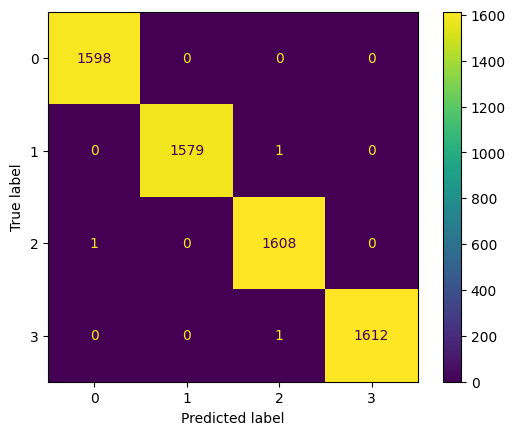

In [8]:
torch.save(model.state_dict(), 'model.pth')
draw_cm(y_test, preds_test, 'ConfMatrix_test')

## Validation

In [9]:
y_val, preds_val = [], []
with torch.no_grad():
    correct, total = 0, 0
    for images, labels in tqdm(valloader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_val.extend(labels.cpu().numpy())
        preds_val.extend(predicted.cpu().numpy())
    acc = 100 * correct / total
    print(f'Accuracy of the network on the {total} validation images:{acc:.3f} %')

100%|██████████| 5/5 [00:02<00:00,  1.87it/s]

Accuracy of the network on the 587 validation images:53.492 %


Precision: 44.583 %
Recall: 37.868 %
F1 Score: 40.952 %
F1 Macro Score: 38.193 %
F1 Weighted Score: 50.735 %


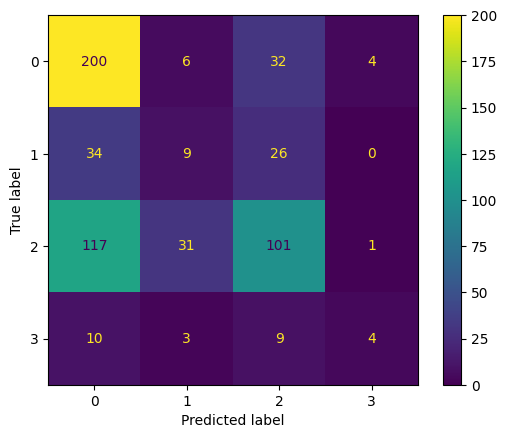

In [10]:
draw_cm(y_val, preds_val, 'ConfMatrix_val')

## Morphological classification

In [11]:
import os
from torch.utils.data import Dataset
from torchvision.io import read_image, ImageReadMode

class AstrogeoDataset(Dataset):
    def __init__(self, dir: str, transform=None) -> None:
        self.transform = transform
        self.images = os.listdir(dir)
        self.dir = dir

    def __getitem__(self, index: int) -> tuple:
        image = read_image(
            f'{self.dir}/{self.images[index]}',
            mode=ImageReadMode.RGB
        )
        file_name = self.images[index]
        if self.transform is not None:
            image = self.transform(image)
        return (file_name, image)

    def __len__(self) -> int:
        return len(self.images)

In [12]:
import json
import pandas as pd

transform = transforms.Compose([
    transforms.ToPILImage(), transforms.Grayscale(),
    transforms.Resize((128, 128)), transforms.ToTensor()
])
morph = AstrogeoDataset(data_path, transform=transform)
morphloader = torch.utils.data.DataLoader(
    morph, batch_size=batch_size, shuffle=True, num_workers=4
)

model.eval()
morph_preds = {}
with torch.no_grad():
    for file_names, images in tqdm(morphloader):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        morph_preds.update(dict(zip(file_names, predicted.cpu().tolist())))
        
with open('predicts.json', 'w') as f:
    json.dump(morph_preds, f)

s1 = pd.Series(morph_preds.keys())
s2 = pd.Series(morph_preds.values())
df = pd.concat([s1, s2], axis=1)
df = df.rename(columns={0: 'file_name', 1: 'predicted_class'})
df.to_csv('classification.csv')

100%|██████████| 1032/1032 [08:04<00:00,  2.13it/s]


{0: 77393, 1: 15234, 2: 36241, 3: 3103}


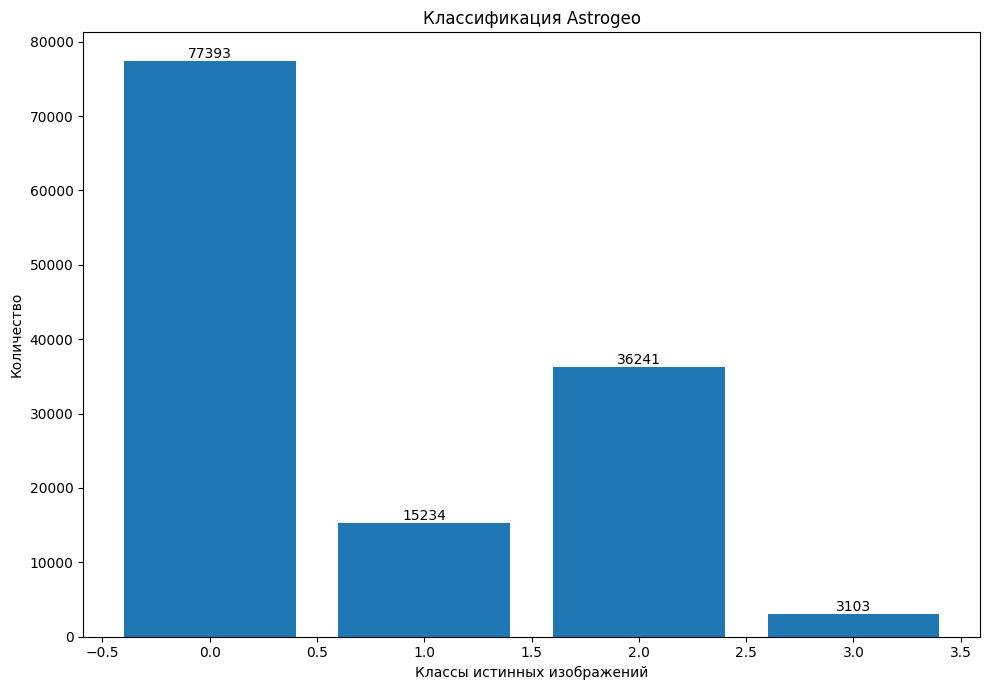

In [13]:
from collections import Counter

labels = [
    'Одиночный источник', 'Двойной источник',
    'Источник с джетом', 'Источник с двойным джетом'
]
res = dict(Counter(morph_preds.values()))
res = {k: v for k, v in sorted(res.items())}
print(res)
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
bar = ax.bar(res.keys(), res.values())
ax.bar_label(bar, labels=res.values())
ax.set_xlabel('Классы истинных изображений')
ax.set_ylabel('Количество')
ax.set_title('Классификация Astrogeo')
fig.tight_layout()
plt.savefig('histogram.png', dpi=500)

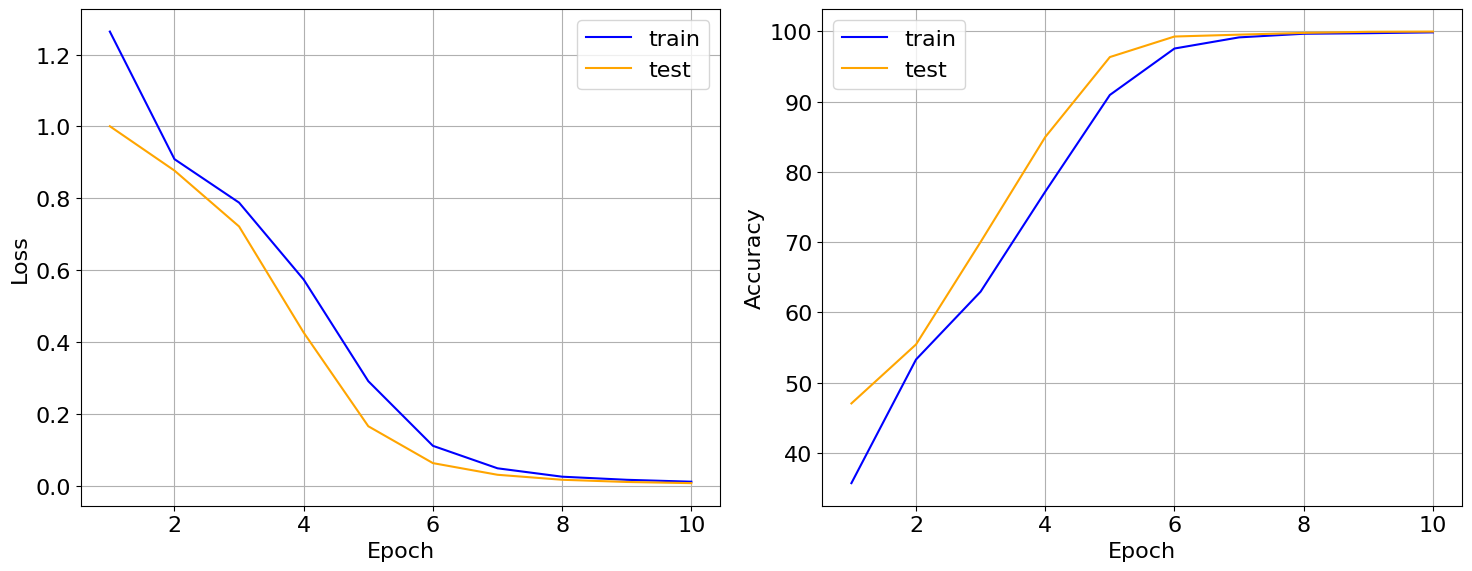

In [14]:
import numpy as np

plt.rcParams.update({'font.size': 16})
epochs = np.arange(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(epochs, LossTrain, label='train', color='blue')
axes[0].plot(epochs, LossTest, label='test', color='orange')
# axes[0].set_title('Loss(epoch)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid()
axes[0].legend()

axes[1].plot(epochs, AccTrain, label='train', color='blue')
axes[1].plot(epochs, AccTest, label='test', color='orange')
# axes[1].set_title('Accuracy(epoch)')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid()
axes[1].legend()
plt.tight_layout()
plt.savefig('train.png', dpi=500)